In [1]:
# Regularization and Data Augmentation for CNNs

In [2]:
# Overfitting in CNNs and Methods to prevent It
# Overfitting:
    # -occurs when a model performs well on the traning data but fails to generalize to unseen data
    # -In CNNs, Overfitting is common due to the large number of parameters in deep networks
    
# Methods to prevent Overfitting:
    # Dropout:
        # -Randomly sets a fraction of neurons to zero during training
        # -Prevents co-adaptations of neurons
        # -Controlled by a dropout rate(ed 0.5)
    # Batch Normalization:
        # -Normalizes the input of each layer to stabilize training
        # -Reduces internal covariate shift and allow higher learning rates
    # Data Augmentation:
        # -Increases dataset size  artifically by applying transformations to images
        # -Examples: Rotation, flipping, scaling, cropping,brightness adjustment.


In [3]:
# Introduction to Data Augmentation Techniques:
# Common techniques:
    # Rotation: Rotates the image by specified angle ranges( eg -30 to 30 degree)
    # Flipping: Horizontally or vertically flip the image
    # Scaling: Resizes the image by zooming in or out
    # Cropping: Extracts random portions of the image

In [4]:
# Implementing Regularization and Data Augmentation in CNN

# Use both:
    # -Regularization reduces the complexity of the model
    # -Data Augmentation increases the diversity of the training data, improving generalization

In [5]:
# Execrcise: Objective:
    # Apply dropout , batch normalization,and data augmentation to improve CNN performance

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 32s 0us/step
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


781/781 ━━━━━━━━━━━━━━━━━━━━ 261s 329ms/step - accuracy: 0.3450 - loss: 2.1540 - val_accuracy: 0.5544 - val_loss: 1.2665
Epoch 2/10
  1/781 ━━━━━━━━━━━━━━━━━━━━ 3:08 242ms/step - accuracy: 0.3750 - loss: 1.6568

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


781/781 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.3750 - loss: 1.6568 - val_accuracy: 0.5547 - val_loss: 1.2651
Epoch 3/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 289s 301ms/step - accuracy: 0.5333 - loss: 1.3197 - val_accuracy: 0.6048 - val_loss: 1.1542
Epoch 4/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.5000 - loss: 1.3867 - val_accuracy: 0.6039 - val_loss: 1.1506
Epoch 5/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 250s 297ms/step - accuracy: 0.5999 - loss: 1.1287 - val_accuracy: 0.6422 - val_loss: 1.0477
Epoch 6/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.5938 - loss: 1.0476 - val_accuracy: 0.6522 - val_loss: 1.0246
Epoch 7/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 237s 303ms/step - accuracy: 0.6354 - loss: 1.0301 - val_accuracy: 0.5817 - val_loss: 1.3082
Epoch 8/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.5938 - loss: 1.0501 - val_accuracy: 0.5647 - val_loss: 1.3800
Epoch 9/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 254s 307ms/step - accuracy: 0.6543 - loss: 0.9774 - val

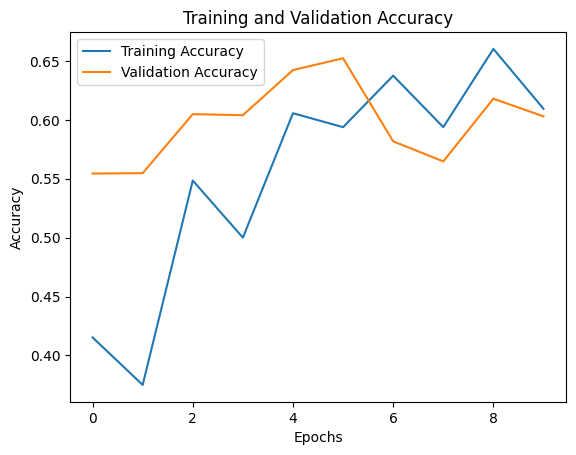

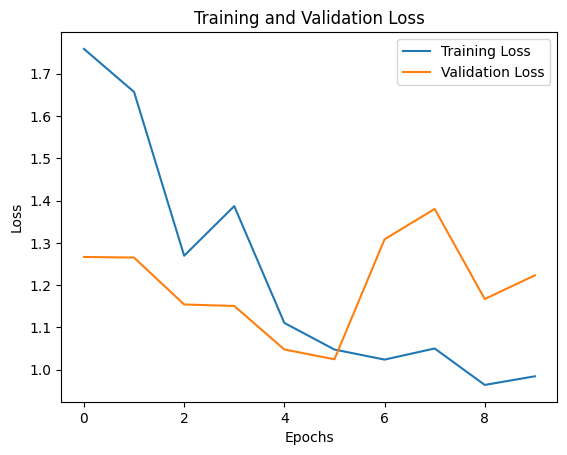

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values to the range [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode the labels
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
# here we are using data augmentation to increase the number of training samples with the help of rotation, width shift, height shift and horizontal flip

# Fit the generator to training data
datagen.fit(x_train)

# creating the model with layers
def create_model():
    model = models.Sequential()
    
    # Convolutional Layer 1
    model.add(layers.Input(shape=(32, 32, 3)))
    model.add(layers.Conv2D(32, (3, 3), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3, 3), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))
    
    # Convolutional Layer 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))
    
    # Fully connected layers
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation='softmax'))
    
    return model
    
    
model = create_model()

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model using the augmented data generator
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=10,
    validation_data=(x_test, y_test),
    steps_per_epoch=x_train.shape[0] // 64
)

test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=2)
print(f"Test Accuracy: {test_accuracy:.2f}")

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

c:\Users\Usha Biratthi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Epoch 1/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 75s 86ms/step - accuracy: 0.3534 - loss: 1.9992 - val_accuracy: 0.4865 - val_loss: 1.4129
Epoch 2/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 51s 65ms/step - accuracy: 0.4766 - loss: 1.4695 - val_accuracy: 0.4880 - val_loss: 1.5191
Epoch 3/10
  1/781 ━━━━━━━━━━━━━━━━━━━━ 46s 59ms/step - accuracy: 0.4688 - loss: 1.3581

c:\Users\Usha Biratthi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


781/781 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4688 - loss: 1.3581 - val_accuracy: 0.4929 - val_loss: 1.5017
Epoch 4/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 50s 65ms/step - accuracy: 0.5346 - loss: 1.2991 - val_accuracy: 0.5618 - val_loss: 1.2936
Epoch 5/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 54s 69ms/step - accuracy: 0.5770 - loss: 1.1931 - val_accuracy: 0.5684 - val_loss: 1.2834
Epoch 6/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6875 - loss: 0.8686 - val_accuracy: 0.5754 - val_loss: 1.2573
Epoch 7/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 60s 77ms/step - accuracy: 0.6035 - loss: 1.1266 - val_accuracy: 0.5464 - val_loss: 1.3433
Epoch 8/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 62s 79ms/step - accuracy: 0.6213 - loss: 1.0742 - val_accuracy: 0.6462 - val_loss: 1.0554
Epoch 9/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6250 - loss: 0.8332 - val_accuracy: 0.6405 - val_loss: 1.0865
Epoch 10/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 54s 70ms/step - accuracy: 0.6327 - loss: 1.0344 - val_accuracy: 0.

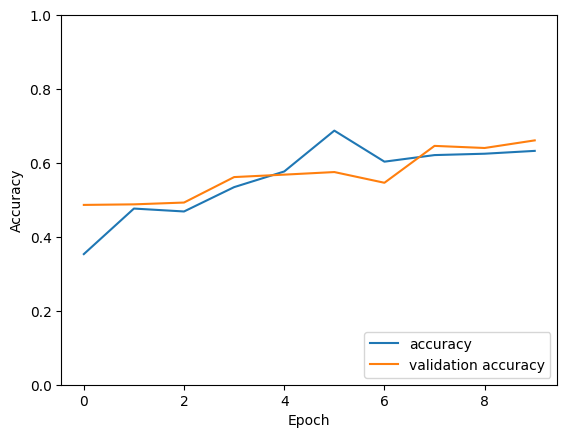

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6611 - loss: 1.0069
Test accuracy: 0.6611


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# load and preproces the CIFAR-10 data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# normalize pixel value to the range [0,1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# one-hot encode the labels
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)
# converts the labels to a one-hot encoded format ex: 3 to [0,0,0,1,0,0,0,0,0,0]

datagen = ImageDataGenerator(
    rotation_range=15, # rotate images by up to 15 degrees
    width_shift_range=0.1, # shift images horizontally by up to 10%
    height_shift_range=0.1, # shift images vertically by up to 10%
    horizontal_flip=True, # flip images horizontally
    # fill_mode='nearest' # fill in new pixels with the nearest neighbor of the original image
)

# fill the generator to training data
datagen.fit(X_train)

# Build the model
def create_model():
    model = models.Sequential()

    # Convolutional block 1
    model.add(layers.Input(shape=(32, 32, 3))) # here 32, 32, 3 is the input shape with 32x32 pixels and 3 color channels (RGB)
    model.add(layers.Conv2D(32, (3, 3), activation='relu')) # 32 filters, 3x3 kernel size, ReLU activation 
    model.add(layers.BatchNormalization()) # Normalization to prevent overfitting
    model.add(layers.Conv2D(32,(3,3), activation='relu')) # 32 filters, 3x3 kernel size, ReLU activation
    model.add(layers.BatchNormalization()) # Normalization to prevent overfitting
    model.add(layers.MaxPooling2D((2,2))) # 2x2 max pooling
    model.add(layers.Dropout(0.25)) # Dropout to prevent overfitting, 25% of the input units are dropped

    # second block
    model.add(layers.Conv2D(64, (3, 3), activation='relu')) # 64 filters, 3x3 kernel size, ReLU activation
    model.add(layers.BatchNormalization()) # Normalization to prevent overfitting
    model.add(layers.Conv2D(64, (3, 3), activation='relu')) # 64 filters, 3x3 kernel size, ReLU activation
    model.add(layers.BatchNormalization()) # Normalization to prevent overfitting
    model.add(layers.MaxPooling2D((2, 2))) # 2x2 max pooling
    model.add(layers.Dropout(0.25)) # Dropout to prevent overfitting, 25% of the input units are dropped

    # fully connected layer
    model.add(layers.Flatten()) # Flatten the output to a 1D vector
    model.add(layers.Dense(512, activation='relu')) # 512 units, ReLU activation
    model.add(layers.BatchNormalization()) # Normalization to prevent overfitting
    model.add(layers.Dropout(0.5)) # Dropout to prevent overfitting, 50% of the input units are dropped
    model.add(layers.Dense(10, activation='softmax')) # 10 units, softmax activation for classification

    return model

# compile the model
model = create_model()
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# train the model
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(X_test, y_test),
    steps_per_epoch=X_train.shape[0] // 64
)

# evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# plot the training and validation accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

# save the model
model.save('cifar10_cnn.h5')

# load the model
model = tf.keras.models.load_model('cifar10_cnn.h5')

# evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")



In [ ]:
# The error is caused by spatial dimension exhaustion. 
# CIFAR-10 images are only 32×32 pixels, but your network uses 5 conv blocks with valid (default) padding — each Conv2D(3×3) shrinks the spatial size by 2, and each MaxPooling2D(2×2) halves it. 
# By Block 4, the feature map has collapsed to 0×0, making the next convolution mathematically impossible.


import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# load and preproces the CIFAR-10 data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# normalize pixel value to the range [0,1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# one-hot encode the labels
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)
# converts the labels to a one-hot encoded format ex: 3 to [0,0,0,1,0,0,0,0,0,0]

datagen = ImageDataGenerator(
    rotation_range=15, # rotate images by up to 15 degrees
    width_shift_range=0.1, # shift images horizontally by up to 10%
    height_shift_range=0.1, # shift images vertically by up to 10%
    horizontal_flip=True, # flip images horizontally
    # fill_mode='nearest' # fill in new pixels with the nearest neighbor of the original image
)

# fill the generator to training data
datagen.fit(X_train)

# Build the model
def create_model():
    model = models.Sequential()

    # Convolutional block 1
    model.add(layers.Input(shape=(32, 32, 3))) # here 32, 32, 3 is the input shape with 32x32 pixels and 3 color channels (RGB)
    model.add(layers.Conv2D(32, (3, 3), activation='relu')) # 32 filters, 3x3 kernel size, ReLU activation 
    model.add(layers.BatchNormalization()) # Normalization to prevent overfitting
    model.add(layers.Conv2D(32,(3,3), activation='relu')) # 32 filters, 3x3 kernel size, ReLU activation
    model.add(layers.BatchNormalization()) # Normalization to prevent overfitting
    model.add(layers.MaxPooling2D((2,2))) # 2x2 max pooling
    model.add(layers.Dropout(0.25)) # Dropout to prevent overfitting, 25% of the input units are dropped

    # second block
    model.add(layers.Conv2D(64, (3, 3), activation='relu')) # 64 filters, 3x3 kernel size, ReLU activation
    model.add(layers.BatchNormalization()) # Normalization to prevent overfitting
    model.add(layers.Conv2D(64, (3, 3), activation='relu')) # 64 filters, 3x3 kernel size, ReLU activation
    model.add(layers.BatchNormalization()) # Normalization to prevent overfitting
    model.add(layers.MaxPooling2D((2, 2))) # 2x2 max pooling
    model.add(layers.Dropout(0.25)) # Dropout to prevent overfitting, 25% of the input units are dropped

    # thrid block
    model.add(layers.Conv2D(128, (3,3), activation='relu')) # 64 filters, 3x3 kernel size, ReLU activation
    model.add(layers.BatchNormalization()) # Normalization to prevent overfitting
    model.add(layers.Conv2D(128, (3, 3), activation='relu')) # 64 filters, 3x3 kernel size, ReLU activation
    model.add(layers.BatchNormalization()) # Normalization to prevent overfitting
    model.add(layers.MaxPooling2D((2, 2))) # 2x2 max pooling
    model.add(layers.Dropout(0.25)) # Dropout to prevent overfitting, 25% of the input units are dropped
 
    # forth block
    model.add(layers.Conv2D(256, (3,3), activation='relu')) # 64 filters, 3x3 kernel size, ReLU activation
    model.add(layers.BatchNormalization()) # Normalization to prevent overfitting
    model.add(layers.Conv2D(256, (3, 3), activation='relu')) # 64 filters, 3x3 kernel size, ReLU activation
    model.add(layers.BatchNormalization()) # Normalization to prevent overfitting
    model.add(layers.MaxPooling2D((2, 2))) # 2x2 max pooling
    model.add(layers.Dropout(0.25)) # Dropout to prevent overfitting, 25% of the input units are dropped

    # fifth block
    model.add(layers.Conv2D(512, (3,3), activation='relu')) # 64 filters, 3x3 kernel size, ReLU activation
    model.add(layers.BatchNormalization()) # Normalization to prevent overfitting
    model.add(layers.Conv2D(512, (3, 3), activation='relu')) # 64 filters, 3x3 kernel size, ReLU activation
    model.add(layers.BatchNormalization()) # Normalization to prevent overfitting
    model.add(layers.MaxPooling2D((2, 2))) # 2x2 max pooling
    model.add(layers.Dropout(0.25)) # Dropout to prevent overfitting, 25% of the input units are dropped

    # fully connected layer
    model.add(layers.Flatten()) # Flatten the output to a 1D vector
    model.add(layers.Dense(512, activation='relu')) # 512 units, ReLU activation
    model.add(layers.BatchNormalization()) # Normalization to prevent overfitting
    model.add(layers.Dropout(0.5)) # Dropout to prevent overfitting, 50% of the input units are dropped
    model.add(layers.Dense(10, activation='softmax')) # 10 units, softmax activation for classification

    return model

# compile the model
model = create_model()
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# train the model
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(X_test, y_test),
    steps_per_epoch=X_train.shape[0] // 64
)

# evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# plot the training and validation accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

# save the model
model.save('cifar10_cnn.h5')

# load the model
model = tf.keras.models.load_model('cifar10_cnn.h5')

# evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")



ValueError: Computed output size would be negative. Received `inputs shape=(None, 0, 0, 128)`, `kernel shape=(3, 3, 128, 256)`, `dilation_rate=[1 1]`.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# load and preproces the CIFAR-10 data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# normalize pixel value to the range [0,1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# one-hot encode the labels
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)
# converts the labels to a one-hot encoded format ex: 3 to [0,0,0,1,0,0,0,0,0,0]

datagen = ImageDataGenerator(
    rotation_range=15, # rotate images by up to 15 degrees
    width_shift_range=0.1, # shift images horizontally by up to 10%
    height_shift_range=0.1, # shift images vertically by up to 10%
    horizontal_flip=True, # flip images horizontally
    # fill_mode='nearest' # fill in new pixels with the nearest neighbor of the original image
)

# fill the generator to training data
datagen.fit(X_train)

# Build the model
def create_model():
    model = models.Sequential()

# padding='same' pads the input so each convolution preserves spatial dimensions, meaning only MaxPooling reduces the size
    
    # Convolutional block 1
    model.add(layers.Input(shape=(32, 32, 3)))
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))  #  padding='same'
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))  
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Block 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))  
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))  
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Block 3
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))  
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))  
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Block 4
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))  
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))  
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Block 5
    model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same')) 
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))  
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Fully connected
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation='softmax'))

    return model


# compile the model
model = create_model()
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# train the model
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(X_test, y_test),
    steps_per_epoch=X_train.shape[0] // 64
)

# evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# plot the training and validation accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

# save the model
model.save('cifar10_cnn.h5')

# load the model
model = tf.keras.models.load_model('cifar10_cnn.h5')

# evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")



c:\Users\Usha Biratthi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Epoch 1/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 369s 416ms/step - accuracy: 0.3207 - loss: 2.0053 - val_accuracy: 0.4388 - val_loss: 1.5886
Epoch 2/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 335s 429ms/step - accuracy: 0.4632 - loss: 1.5169 - val_accuracy: 0.4357 - val_loss: 1.8296
Epoch 3/10
  1/781 ━━━━━━━━━━━━━━━━━━━━ 4:47 369ms/step - accuracy: 0.4688 - loss: 1.3231

c:\Users\Usha Biratthi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


781/781 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.4688 - loss: 1.3231 - val_accuracy: 0.4345 - val_loss: 1.8498
Epoch 4/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 319s 408ms/step - accuracy: 0.5440 - loss: 1.2983 - val_accuracy: 0.5003 - val_loss: 1.5472
Epoch 5/10
508/781 ━━━━━━━━━━━━━━━━━━━━ 2:11 483ms/step - accuracy: 0.5858 - loss: 1.1990

KeyboardInterrupt: 

c:\Users\Usha Biratthi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")
c:\Users\Usha Biratthi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 32ms/step - accuracy: 0.4431 - loss: 1.5273 - val_accuracy: 0.5483 - val_loss: 1.2610
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.5886 - loss: 1.1644 - val_accuracy: 0.6079 - val_loss: 1.0973
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.6422 - loss: 1.0124 - val_accuracy: 0.6559 - val_loss: 0.9850
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.6802 - loss: 0.9110 - val_accuracy: 0.6332 - val_loss: 1.0441
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.7066 - loss: 0.8388 - val_accuracy: 0.6814 - val_loss: 0.9384
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.7272 - loss: 0.7769 - val_accuracy: 0.6763 - val_loss: 0.9224
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.7433 - loss: 0.7286 - val_accuracy: 0.7090 - val_loss: 0.8374
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.7622 -

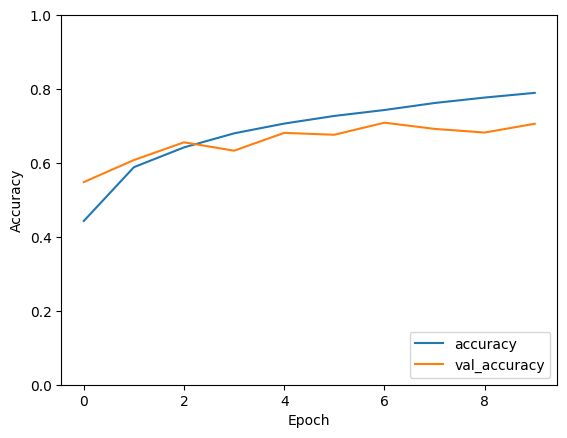

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# load and preproces the CIFAR-10 data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# normalize the data
X_train = X_train / 255.0
X_test = X_test / 255.0

# build the model
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

# compile the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# train the model
history = model.fit(X_train, y_train, epochs=10, 
                    validation_data=(X_test, y_test))

# evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc}")

# plot the training and validation accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

# plot the training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title("Training and Validation Loss")
plt.legend()
plt.show()
